In [1]:
!pip install pandas numpy matplotlib scikit-learn yfinance joblib

In [2]:
import numpy as np
import pandas as pd
import math
import joblib
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
stock = "AAPL"
data = yf.download(stock, start="2015-01-01", end="2026-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214890,24.682222,23.776350,24.671147,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534941,23.794077,23.173920,23.596956,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


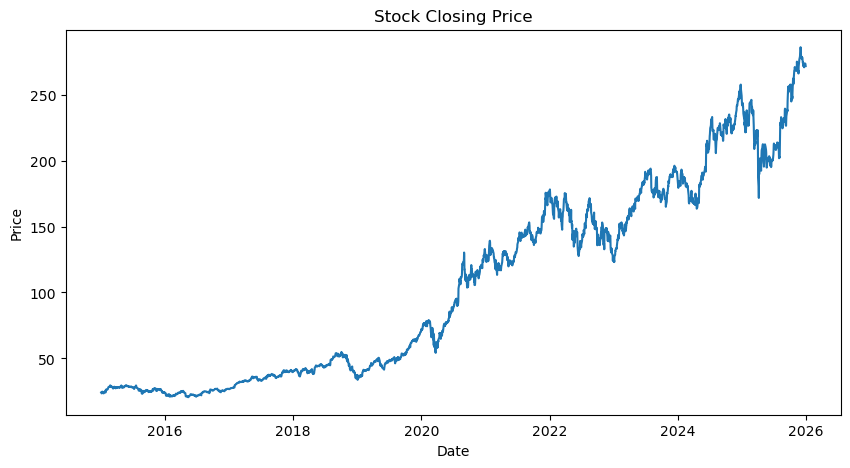

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [5]:
data = data[['Close']]
data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214890
2015-01-05,23.532722
2015-01-06,23.534941
2015-01-07,23.864948
2015-01-08,24.781891


In [6]:
data['Prev1'] = data['Close'].shift(1)
data['Prev2'] = data['Close'].shift(2)
data['Prev3'] = data['Close'].shift(3)
data.dropna(inplace=True)
data.head()

Price,Close,Prev1,Prev2,Prev3
Ticker,AAPL,,,
Date,,,,
2015-01-07,23.864948,23.534941,23.532722,24.214890
2015-01-08,24.781891,23.864948,23.534941,23.532722
2015-01-09,24.808475,24.781891,23.864948,23.534941
2015-01-12,24.197176,24.808475,24.781891,23.864948
2015-01-13,24.412016,24.197176,24.808475,24.781891


In [7]:
X = data[['Prev1', 'Prev2', 'Prev3']]
y = data['Close']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [9]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

E:\Anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
predictions = model.predict(X_test)

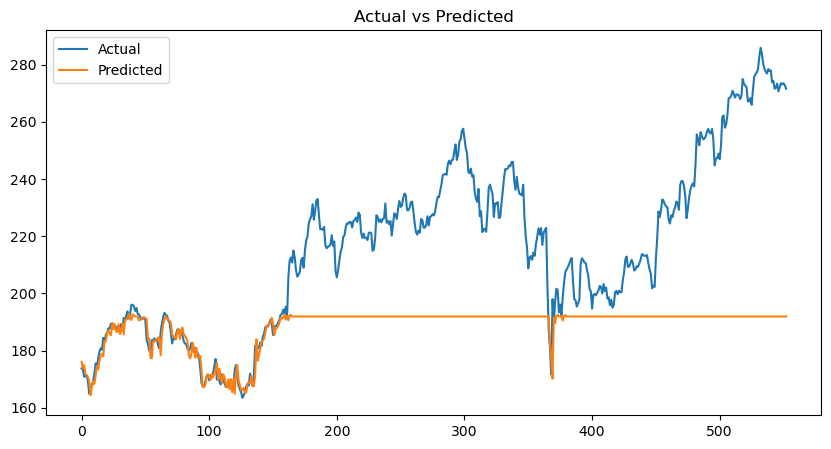

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [12]:
rmse = math.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

RMSE: 36.95812754718233


In [13]:
last_values = X.iloc[-1].values.reshape(1, -1)
next_price = model.predict(last_values)
print("Next Day Prediction:", next_price[0])

Next Day Prediction: 191.94059677124022


In [14]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [15]:
import joblib
import os

# save model directly into your project folder
path = r"C:\Users\hp\Desktop\stock-project\model.pkl"
joblib.dump(model, path)

print("Saved at:", path)

Saved at: C:\Users\hp\Desktop\stock-project\model.pkl
